# EDA — Análisis de Criminalidad en Chicago (2020–2024)

Análisis exploratorio de datos sobre el dataset de criminalidad de Chicago (Chicago Data Portal).

**Contenido de este notebook:**
1. Carga y limpieza de datos
2. Conversión de fechas y variables temporales
3. Análisis exploratorio (tipos de crimen, ubicaciones, arrestos)
4. Análisis con SQL (carga a SQL Server y consultas con Window Functions)
5. Visualización geográfica (mapa de calor)
6. Análisis temporal (franjas horarias, estacionalidad, distritos)
7. Incorporación de datos de población y cálculo de tasas por habitante


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

pd.set_option("display.max_columns", None)

## 1. Carga y limpieza de datos

In [5]:
# Dataset original: Chicago Crime Data (Chicago Data Portal)
# Coloca el CSV en la carpeta data/ antes de ejecutar
df = pd.read_csv("../data/Proyecto Bootcamp.csv")
df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,3,10508693,HZ250496,05/03/2024 11:40:00 PM,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)"
1,89,10508695,HZ250409,05/03/2024 09:40:00 PM,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)"
2,197,10508697,HZ250503,05/03/2024 11:31:00 PM,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)"
3,673,10508698,HZ250424,05/03/2024 10:10:00 PM,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)"
4,911,10508699,HZ250455,05/03/2024 10:00:00 PM,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456714 entries, 0 to 1456713
Data columns (total 23 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Unnamed: 0            1456714 non-null  int64  
 1   ID                    1456714 non-null  int64  
 2   Case Number           1456713 non-null  object 
 3   Date                  1456714 non-null  object 
 4   Block                 1456714 non-null  object 
 5   IUCR                  1456714 non-null  object 
 6   Primary Type          1456714 non-null  object 
 7   Description           1456714 non-null  object 
 8   Location Description  1455056 non-null  object 
 9   Arrest                1456714 non-null  bool   
 10  Domestic              1456714 non-null  bool   
 11  Beat                  1456714 non-null  int64  
 12  District              1456713 non-null  float64
 13  Ward                  1456700 non-null  float64
 14  Community Area        1456674 non-

In [7]:
df.describe()

,Unnamed: 0,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,1.456714e+06,1.456714e+06,1.456714e+06,1.456713e+06,1.456700e+06,1.456674e+06,1.419631e+06,1.419631e+06,1.456714e+06,1.419631e+06,1.419631e+06
mean,3.308606e+06,9.597550e+06,1.150644e+03,1.125920e+01,2.287027e+01,3.745632e+01,1.164398e+06,1.885523e+06,2.013897e+03,4.184147e+01,-8.767224e+01
std,1.235350e+06,8.083505e+05,6.916466e+02,6.904691e+00,1.380589e+01,2.144029e+01,1.850835e+04,3.424775e+04,1.449584e+00,9.430126e-02,6.661726e-02
min,3.000000e+00,2.022400e+04,1.110000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.012000e+03,3.661945e+01,-9.168657e+01
25%,2.698636e+06,9.002709e+06,6.130000e+02,6.000000e+00,1.000000e+01,2.300000e+01,1.152544e+06,1.858762e+06,2.013000e+03,4.176787e+01,-8.771528e+01
50%,3.063654e+06,9.605776e+06,1.024000e+03,1.000000e+01,2.300000e+01,3.200000e+01,1.166021e+06,1.891502e+06,2.014000e+03,4.185797e+01,-8.766613e+01
75%,3.428849e+06,1.022577e+07,1.711000e+03,1.700000e+01,3.400000e+01,5.600000e+01,1.176363e+06,1.908713e+06,2.015000e+03,4.190529e+01,-8.762813e+01
max,6.253474e+06,1.082788e+07,2.535000e+03,3.100000e+01,5.000000e+01,7.700000e+01,1.205119e+06,1.951573e+06,2.017000e+03,4.202271e+01,-8.752453e+01


In [8]:
df.isnull().sum()

Unnamed: 0                  0
ID                          0
Case Number                 1
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1658
Arrest                      0
Domestic                    0
Beat                        0
District                    1
Ward                       14
Community Area             40
FBI Code                    0
X Coordinate            37083
Y Coordinate            37083
Year                        0
Updated On                  0
Latitude                37083
Longitude               37083
Location                37083
dtype: int64

In [9]:
# Eliminamos filas con valores nulos (principalmente en Location Description,
# District, Ward, Community Area y coordenadas)
df = df.dropna()
df.isnull().sum().sum()  # confirmamos que ya no quedan nulos

np.int64(0)

In [10]:
# Comprobación de duplicados
print("Filas totalmente duplicadas:", df.duplicated().sum())
print("IDs duplicados:", df.duplicated(subset="ID").sum())
# No hay registros duplicados

Filas totalmente duplicadas: 0
IDs duplicados: 0


## 2. Conversión de fechas y variables temporales

In [11]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Hour"] = df["Date"].dt.hour

df[["Date", "Year", "Month", "Hour"]].head()

,Date,Year,Month,Hour
0,2024-05-03 23:40:00,2024,5,23
1,2024-05-03 21:40:00,2024,5,21
2,2024-05-03 23:31:00,2024,5,23
3,2024-05-03 22:10:00,2024,5,22
4,2024-05-03 22:00:00,2024,5,22


In [12]:
df.groupby("Year")["Year"].count()

Year
2020    334397
2021    304267
2022    269329
2023    259610
2024    250732
2025        30
Name: Year, dtype: int64

**Observación:** el año 2025 aparece con muy pocos registros (apenas los primeros días),
lo que sesgaría cualquier análisis anual. Lo excluimos del análisis principal.

In [13]:
df_analisis = df[df["Year"] != 2025].copy()
df_analisis.groupby("Year")["Year"].count()

Year
2020    334397
2021    304267
2022    269329
2023    259610
2024    250732
Name: Year, dtype: int64

## 3. Primeros análisis exploratorios

In [14]:
df_analisis["Primary Type"].value_counts().head(10)
# THEFT, BATTERY, CRIMINAL DAMAGE y NARCOTICS son los crímenes más frecuentes

Primary Type
THEFT                  321950
BATTERY                258941
CRIMINAL DAMAGE        152812
NARCOTICS              131177
ASSAULT                 89508
OTHER OFFENSE           85361
BURGLARY                81668
DECEPTIVE PRACTICE      67609
MOTOR VEHICLE THEFT     59856
ROBBERY                 56092
Name: count, dtype: int64

In [15]:
df_analisis["Location Description"].value_counts().head(10)
# La mayoría de los crímenes ocurren en la calle y en viviendas

Location Description
STREET                            325066
RESIDENCE                         223854
APARTMENT                         179443
SIDEWALK                          158478
OTHER                              53474
PARKING LOT/GARAGE(NON.RESID.)     40907
ALLEY                              31235
RESIDENTIAL YARD (FRONT/BACK)      30209
SMALL RETAIL STORE                 28209
SCHOOL, PUBLIC, BUILDING           25474
Name: count, dtype: int64

In [16]:
df_analisis["Arrest"].value_counts()
# La mayoría de los crímenes no terminan en arresto

Arrest
False    1047278
True      371057
Name: count, dtype: int64

In [17]:
df_analisis["Domestic"].value_counts()
# La mayoría de los crímenes no son de naturaleza doméstica

Domestic
False    1203201
True      215134
Name: count, dtype: int64

In [18]:
print(df_analisis["Community Area"].value_counts().tail())
# Community Area 0.0 tiene un único registro (caso atípico) -> se elimina para no sesgar
df_analisis = df_analisis[df_analisis["Community Area"] != 0.0]

Community Area
18.0    3109
12.0    2454
47.0    2144
9.0     1385
0.0        1
Name: count, dtype: int64


## 4. Análisis con SQL Server

Para practicar SQL avanzado (Window Functions, agregaciones), se cargó el dataset limpio a una base de datos SQL Server local y se realizaron las consultas que se muestran a continuación. **Nota:** esta celda de conexión es solo ilustrativa del proceso original; para que el notebook sea reproducible sin una instancia de SQL Server, las consultas se han traducido también a pandas en las celdas siguientes.

In [19]:
# --- Conexión original a SQL Server (ilustrativa, requiere una instancia local) ---
# from sqlalchemy import create_engine
# engine = create_engine(
#     "mssql+pyodbc://SERVIDOR/SQLEXPRESS/ProyectoBootcamp"
#     "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
# )
# df_analisis.to_sql("Proyecto_Bootcamp", engine, if_exists="replace", index=False)

In [20]:
# Consulta SQL original:
#
# SELECT Year, COUNT(*) AS Crimenes_Año
# FROM Proyecto_Bootcamp
# WHERE Year != 2025
# GROUP BY Year
# ORDER BY Year ASC

crimenes_año = df_analisis.groupby("Year").size().reset_index(name="Crimenes_Año")
crimenes_año

,Year,Crimenes_Año
0,2020,334396
1,2021,304267
2,2022,269329
3,2023,259610
4,2024,250732


In [21]:
crimenes_año["Crimenes_Año"].mean()

np.float64(283666.8)

**2020 y 2021 son los únicos años por encima de la media de crímenes anuales.**

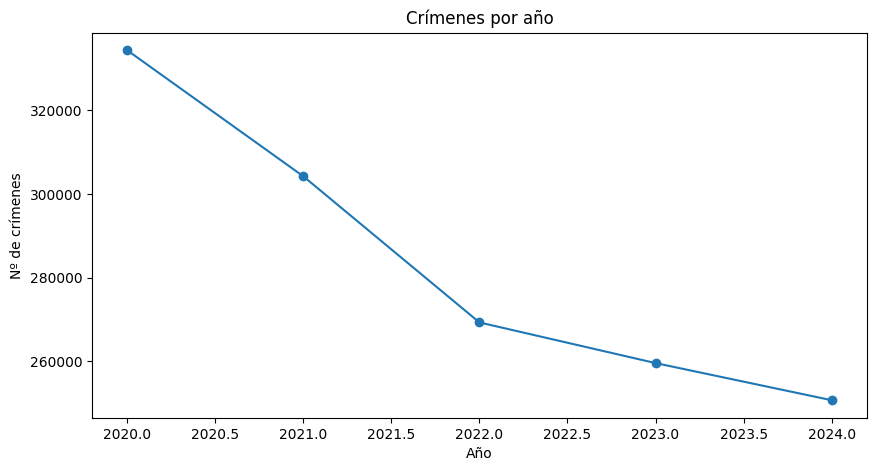

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(crimenes_año["Year"], crimenes_año["Crimenes_Año"], marker="o")
plt.title("Crímenes por año")
plt.xlabel("Año")
plt.ylabel("Nº de crímenes")
plt.show()

**Tendencia bajista**: el número de crímenes disminuye año a año desde 2020 hasta 2024.

In [23]:
# Consulta SQL original:
#
# SELECT Year, [Primary Type], Crimenes_Año
# FROM (
#     SELECT Year, [Primary Type], COUNT(*) AS Crimenes_Año,
#            ROW_NUMBER() OVER (PARTITION BY Year ORDER BY COUNT(*) DESC) AS rn
#     FROM Proyecto_Bootcamp
#     WHERE Year != 2025
#     GROUP BY Year, [Primary Type]
# ) sub
# WHERE rn <= 5
# ORDER BY Year DESC, Crimenes_Año DESC

tipos_crimenes_año = (
    df_analisis.groupby(["Year", "Primary Type"])
    .size()
    .reset_index(name="Crimenes_Año")
)
tipos_crimenes_año["rn"] = (
    tipos_crimenes_año.groupby("Year")["Crimenes_Año"]
    .rank(method="first", ascending=False)
)
top5_tipos_año = (
    tipos_crimenes_año[tipos_crimenes_año["rn"] <= 5]
    .sort_values(["Year", "Crimenes_Año"], ascending=[False, False])
)
top5_tipos_año.head(10)

,Year,Primary Type,Crimenes_Año,rn
156,2024,THEFT,58328,1.0
127,2024,BATTERY,48686,2.0
131,2024,CRIMINAL DAMAGE,30189,3.0
126,2024,ASSAULT,18080,4.0
149,2024,OTHER OFFENSE,15910,5.0
123,2023,THEFT,56830,1.0
95,2023,BATTERY,48579,2.0
99,2023,CRIMINAL DAMAGE,28526,3.0
110,2023,NARCOTICS,22839,4.0
116,2023,OTHER OFFENSE,17405,5.0


**THEFT es el tipo de crimen más cometido en todos los años, seguido siempre por BATTERY en segundo lugar.**

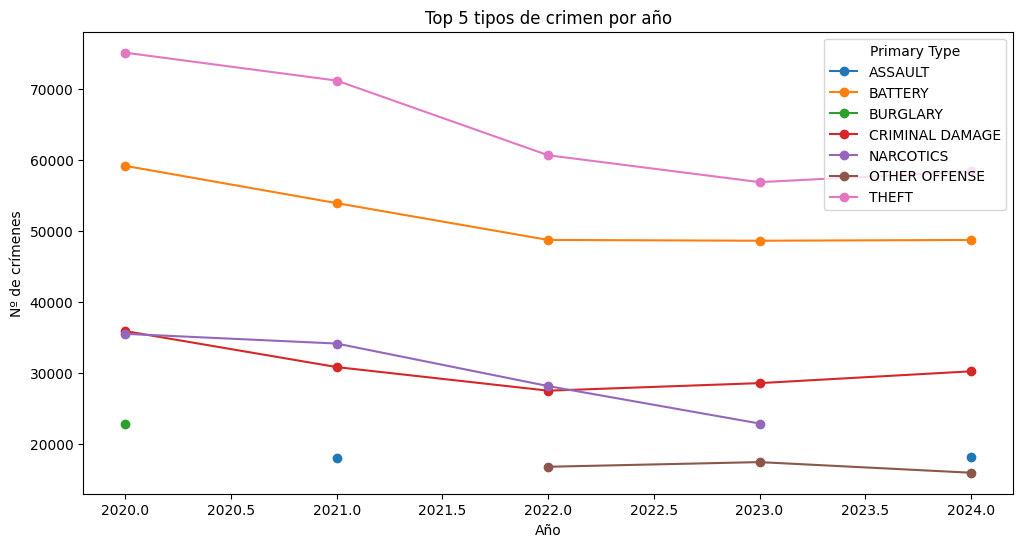

In [24]:
ax = top5_tipos_año.pivot(index="Year", columns="Primary Type", values="Crimenes_Año").plot(
    kind="line", figsize=(12, 6), marker="o"
)
plt.title("Top 5 tipos de crimen por año")
plt.xlabel("Año")
plt.ylabel("Nº de crímenes")
plt.show()

**NARCOTICS desciende a partir de 2022, dejando el tercer puesto a CRIMINAL DAMAGE.**

In [25]:
# Consulta SQL original (Window Function por Ward):
#
# SELECT Ward, [Location Description], Total_Crimenes
# FROM (
#     SELECT Ward, [Location Description], COUNT(*) AS Total_Crimenes,
#            ROW_NUMBER() OVER (PARTITION BY Ward ORDER BY COUNT(*) DESC) AS rn
#     FROM Proyecto_Bootcamp
#     GROUP BY Ward, [Location Description]
# ) sub
# WHERE rn <= 2
# ORDER BY Ward ASC, Total_Crimenes DESC

ward_location = (
    df_analisis.groupby(["Ward", "Location Description"])
    .size()
    .reset_index(name="Total_Crimenes")
)
ward_location["rn"] = (
    ward_location.groupby("Ward")["Total_Crimenes"]
    .rank(method="first", ascending=False)
)
top2_location_ward = (
    ward_location[ward_location["rn"] <= 2]
    .sort_values(["Ward", "Total_Crimenes"], ascending=[True, False])
)
top2_location_ward.head(10)

,Ward,Location Description,Total_Crimenes,rn
73,1.0,STREET,7357,1.0
60,1.0,RESIDENCE,2544,2.0
165,2.0,STREET,10756,1.0
162,2.0,SIDEWALK,5450,2.0
256,3.0,STREET,8682,1.0
178,3.0,APARTMENT,5220,2.0
338,4.0,STREET,5813,1.0
270,4.0,APARTMENT,4579,2.0
353,5.0,APARTMENT,8805,1.0
424,5.0,STREET,7190,2.0


## 5. Visualización geográfica

In [26]:
# Mapa de calor con muestra aleatoria de 50.000 registros (para no saturar el render)
import os
os.makedirs("../outputs", exist_ok=True)

muestra = df_analisis[["Latitude", "Longitude"]].dropna().sample(50000, random_state=42)

mapa = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(muestra.values.tolist()).add_to(mapa)
mapa.save("../outputs/mapa_crimenes.html")
mapa

**El mapa muestra que la mayoría de los crímenes se concentran en las zonas céntricas de Chicago, mientras que las zonas exteriores son comparativamente más seguras.**

## 6. Análisis temporal: franjas horarias y estacionalidad

In [27]:
mañana = df_analisis[(df_analisis["Hour"] >= 6) & (df_analisis["Hour"] < 18)]
noche = df_analisis[(df_analisis["Hour"] >= 18) | (df_analisis["Hour"] < 6)]

print(f"Crímenes de día:   {len(mañana):,}")
print(f"Crímenes de noche: {len(noche):,}")

Crímenes de día:   745,663
Crímenes de noche: 672,671


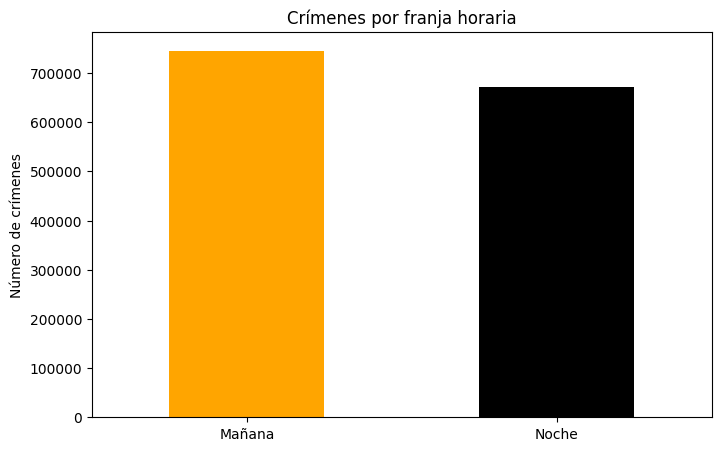

In [28]:
pd.Series({"Mañana": len(mañana), "Noche": len(noche)}).plot(
    kind="bar", figsize=(8, 5), color=["orange", "black"]
)
plt.title("Crímenes por franja horaria")
plt.ylabel("Número de crímenes")
plt.xticks(rotation=0)
plt.show()

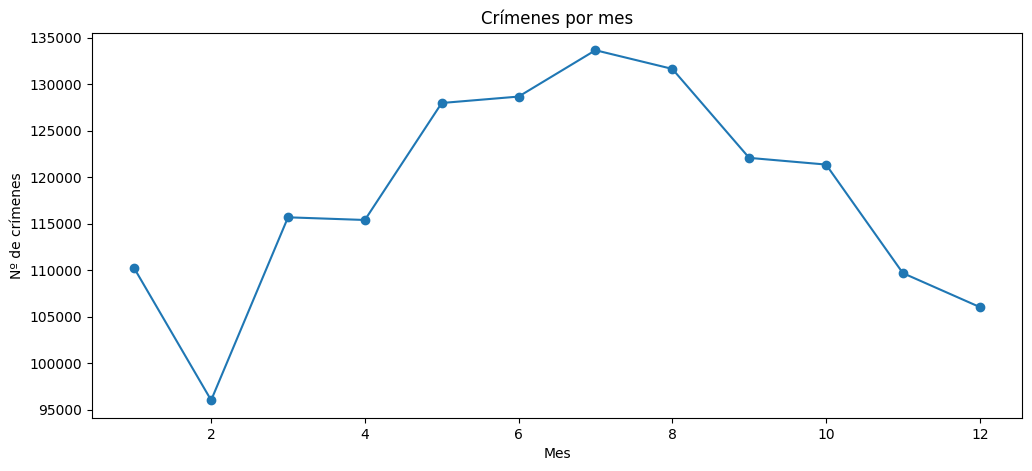

In [29]:
crimenes_mes = df_analisis.groupby("Month")["Month"].count()

plt.figure(figsize=(12, 5))
plt.plot(crimenes_mes.index, crimenes_mes.values, marker="o")
plt.title("Crímenes por mes")
plt.xlabel("Mes")
plt.ylabel("Nº de crímenes")
plt.show()

**Pico de crímenes en los meses de verano.**

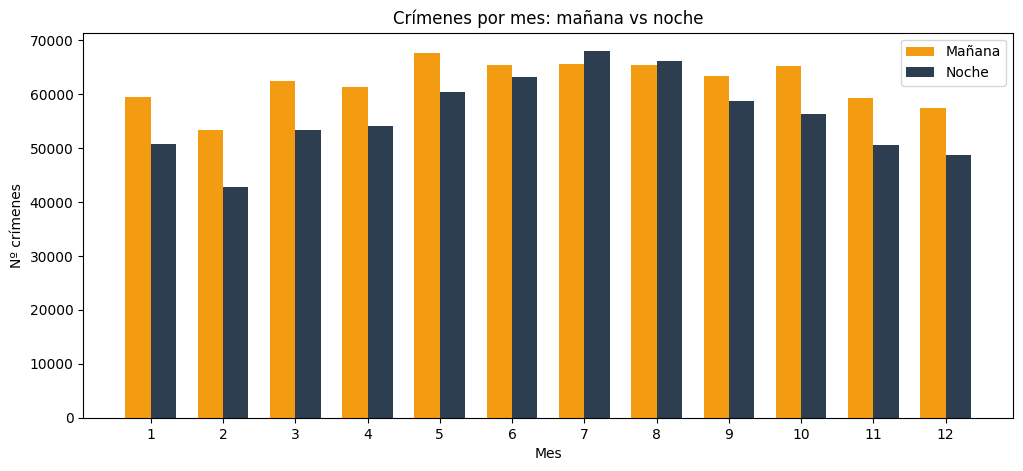

In [30]:
mañana_mes = mañana.groupby("Month")["Month"].count()
noche_mes = noche.groupby("Month")["Month"].count()

x = np.arange(1, 13)
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, mañana_mes.values, width, label="Mañana", color="#f39c12")
plt.bar(x + width / 2, noche_mes.values, width, label="Noche", color="#2c3e50")
plt.title("Crímenes por mes: mañana vs noche")
plt.xlabel("Mes")
plt.ylabel("Nº crímenes")
plt.xticks(x)
plt.legend()
plt.show()

**En los meses de verano (julio y agosto) hay más crímenes nocturnos que diurnos, a diferencia del resto del año.**

## 7. Análisis por distrito

In [31]:
crimenes_district = df_analisis.groupby("District")["District"].count()

# Distritos 13 y 31 excluidos: muestra demasiado pequeña para ser representativa
df_analisis = df_analisis[~df_analisis["District"].isin([13, 31])]
crimenes_district = crimenes_district.drop(index=[13, 31], errors="ignore")

media_distrito = crimenes_district.mean()
media_distrito

np.float64(64468.5)

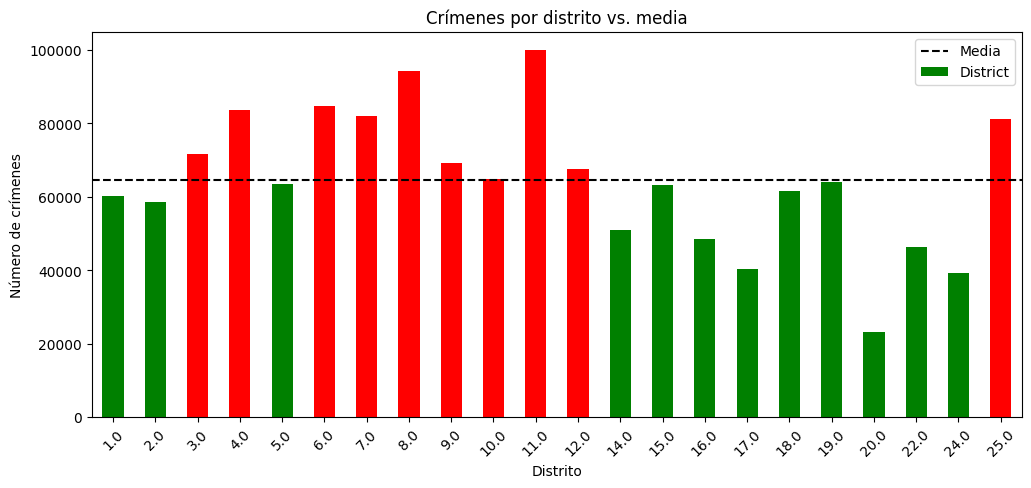

In [32]:
crimenes_district.plot(
    kind="bar", figsize=(12, 5),
    color=["red" if v > media_distrito else "green" for v in crimenes_district]
)
plt.axhline(y=media_distrito, color="black", linestyle="--", label="Media")
plt.title("Crímenes por distrito vs. media")
plt.xlabel("Distrito")
plt.ylabel("Número de crímenes")
plt.legend()
plt.xticks(rotation=45)
plt.show()

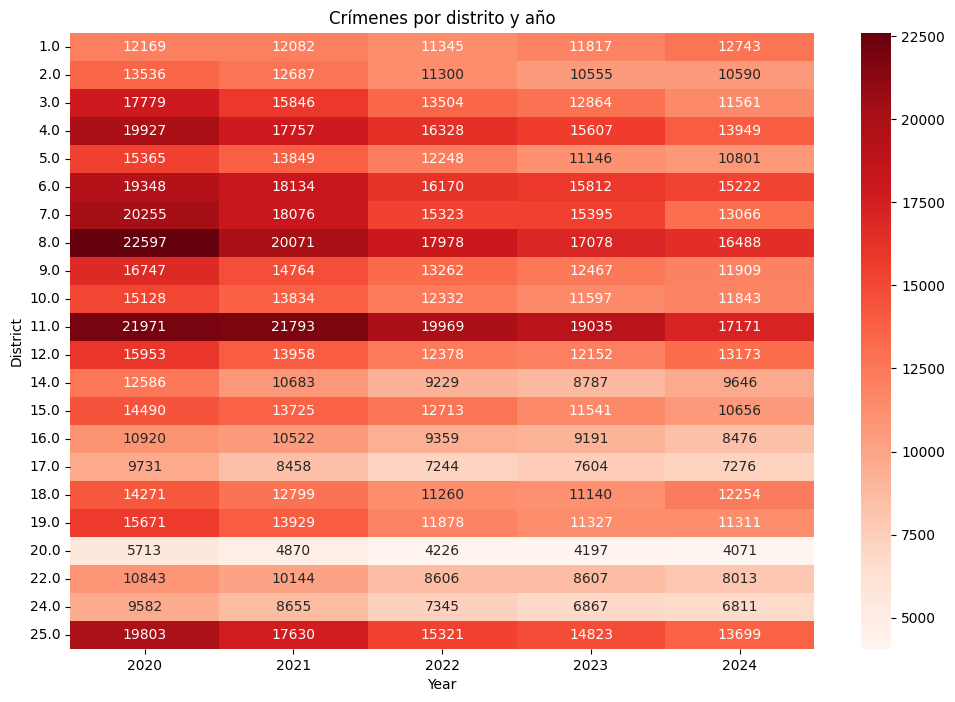

In [33]:
pivot = df_analisis.groupby(["District", "Year"]).size().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt="g")
plt.title("Crímenes por distrito y año")
plt.show()

## 8. Incorporación de población y normalización por habitante

Fuentes externas utilizadas para enriquecer el análisis con datos de población:
- [Chicago Community Area Income and Demographic Data (Kaggle)](https://www.kaggle.com/datasets/aniket0712/acs-5-year-data-by-community-area/data)
- [Chicago Police Department — Investigatory Stop Reports](https://igchicago.org/information-portal/data-dashboards/investigatory-stop-reports-overview/)

In [34]:
# Población estimada por distrito (fuente: datos demográficos de Chicago)
poblacion_distrito = pd.DataFrame({
    "District": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22, 24, 25],
    "Poblacion": [108582, 98409, 84699, 141607, 92674, 120443, 65496, 165116, 114354, 95958,
                  102960, 134834, 148819, 91894, 162112, 121556, 196446, 179355, 106478,
                  105420, 121986, 200999]
})

df_analisis["District"] = df_analisis["District"].astype(int)
df_analisis = df_analisis.merge(poblacion_distrito, on="District", how="left")
df_analisis.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Month,Hour,Poblacion
0,3,10508693,HZ250496,2024-05-03 23:40:00,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10,24.0,29.0,08B,1154907.0,1893681.0,2024,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)",5,23,95958
1,89,10508695,HZ250409,2024-05-03 21:40:00,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3,20.0,42.0,08B,1183066.0,1864330.0,2024,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)",5,21,84699
2,197,10508697,HZ250503,2024-05-03 23:31:00,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15,37.0,25.0,24,1140789.0,1904819.0,2024,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)",5,23,91894
3,673,10508698,HZ250424,2024-05-03 22:10:00,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15,28.0,25.0,08B,1143223.0,1901475.0,2024,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)",5,22,91894
4,911,10508699,HZ250455,2024-05-03 22:00:00,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15,28.0,25.0,06,1139890.0,1901675.0,2024,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)",5,22,91894


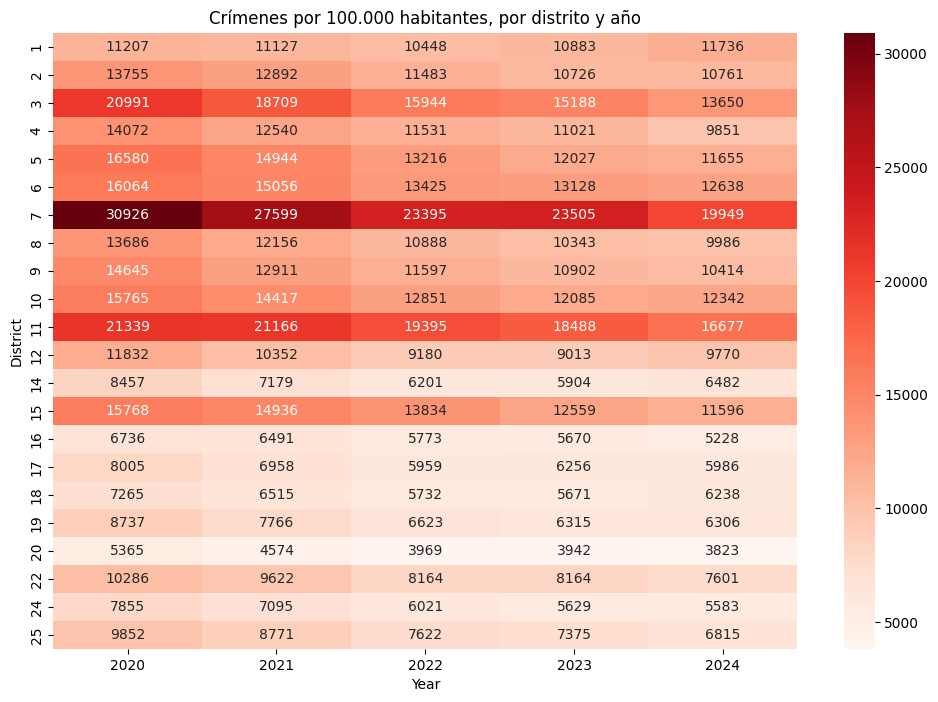

In [35]:
crimenes_distrito = (
    df_analisis.groupby(["District", "Year"]).size().reset_index(name="Crimenes")
)
crimenes_distrito = crimenes_distrito.merge(poblacion_distrito, on="District", how="left")
crimenes_distrito["Crimenes_per_capita"] = (
    crimenes_distrito["Crimenes"] / crimenes_distrito["Poblacion"] * 100000
)

pivot_pc = crimenes_distrito.pivot(index="District", columns="Year", values="Crimenes_per_capita")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_pc, cmap="Reds", annot=True, fmt=".0f")
plt.title("Crímenes por 100.000 habitantes, por distrito y año")
plt.show()

## 9. Variables dummy y correlaciones

In [36]:
df_analisis["Arrest_dummy"] = df_analisis["Arrest"].astype(int)
df_analisis["Domestic_dummy"] = df_analisis["Domestic"].astype(int)

df_analisis[["Poblacion", "Arrest_dummy", "Domestic_dummy", "Hour", "Month", "District"]].corr()

,Poblacion,Arrest_dummy,Domestic_dummy,Hour,Month,District
Poblacion,1.000000,-0.068721,-0.077048,-0.022052,0.007695,0.536325
Arrest_dummy,-0.068721,1.000000,-0.062748,0.086228,-0.040238,-0.021227
Domestic_dummy,-0.077048,-0.062748,1.000000,-0.040587,-0.007689,-0.046200
Hour,-0.022052,0.086228,-0.040587,1.000000,-0.000835,-0.010991
Month,0.007695,-0.040238,-0.007689,-0.000835,1.000000,0.001863
District,0.536325,-0.021227,-0.046200,-0.010991,0.001863,1.000000


## Conclusiones del EDA

- El volumen total de crímenes muestra una **tendencia bajista** entre 2020 y 2024.
- **THEFT** y **BATTERY** son, de forma consistente, los dos tipos de crimen más frecuentes cada año.
- La mayoría de los crímenes ocurren en la **vía pública** y en **viviendas**, y no terminan en arresto.
- Existe una clara **estacionalidad**: los meses de verano concentran más crímenes que el resto del año,
  con un patrón nocturno más marcado en julio y agosto.
- La distribución geográfica **no es homogénea**: hay distritos con tasas de criminalidad muy por
  encima de la media, incluso normalizando por población.

Estos hallazgos —especialmente la relación entre criminalidad y variables socioeconómicas— se
amplían en el notebook `02_exploracion_modelos.ipynb` y se formalizan en el modelo predictivo final
(`03_modelo_final.ipynb`).
